### 模块一：流量、时序与大盘转化率分析
本模块完成：
1. 大盘每日流量趋势（UV、人均PV）
2. 用户24小时行为时序分布
3. 全站活跃用户转化漏斗

初始化环境，加载底表。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 配置绘图风格与中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

# 初始化目录路径
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')

# 自动创建 outputs 文件夹
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# 加载数据
df_sample = pd.read_parquet(os.path.join(DATA_DIR, 'taobao_sample_50k.parquet'))
df_daily = pd.read_parquet(os.path.join(DATA_DIR, 'user_daily.parquet'))

print(f"环境初始化完毕。明细表样本量: {df_sample.shape[0]}，日聚合表样本量: {df_daily.shape[0]}")

环境初始化完毕。明细表样本量: 5021504，日聚合表样本量: 348926


1.大盘日流量指标
计算每日总点击量（PV）、独立访客数（UV）以及人均浏览量（PV/UV）

In [2]:
# 计算日流量指标
traffic_daily = df_daily.groupby('date').agg(
    total_pv=('pv', 'sum'),
    total_uv=('user_id', 'nunique')
).reset_index()

# 计算人均PV
traffic_daily['pv_per_uv'] = (traffic_daily['total_pv'] / traffic_daily['total_uv']).round(2)

# 结果导出至 data 文件夹
traffic_daily.to_csv(os.path.join(DATA_DIR, 'output_traffic_daily.csv'), index=False)
traffic_daily

,date,total_pv,total_uv,pv_per_uv
0,2017-11-25,484795,35654,13.60
1,2017-11-26,483075,36083,13.39
2,2017-11-27,452656,35846,12.63
3,2017-11-28,451820,35873,12.59
4,2017-11-29,465854,36224,12.86
5,2017-11-30,477521,36904,12.94
6,2017-12-01,512138,38248,13.39
7,2017-12-02,628644,47690,13.18
8,2017-12-03,543161,46404,11.71


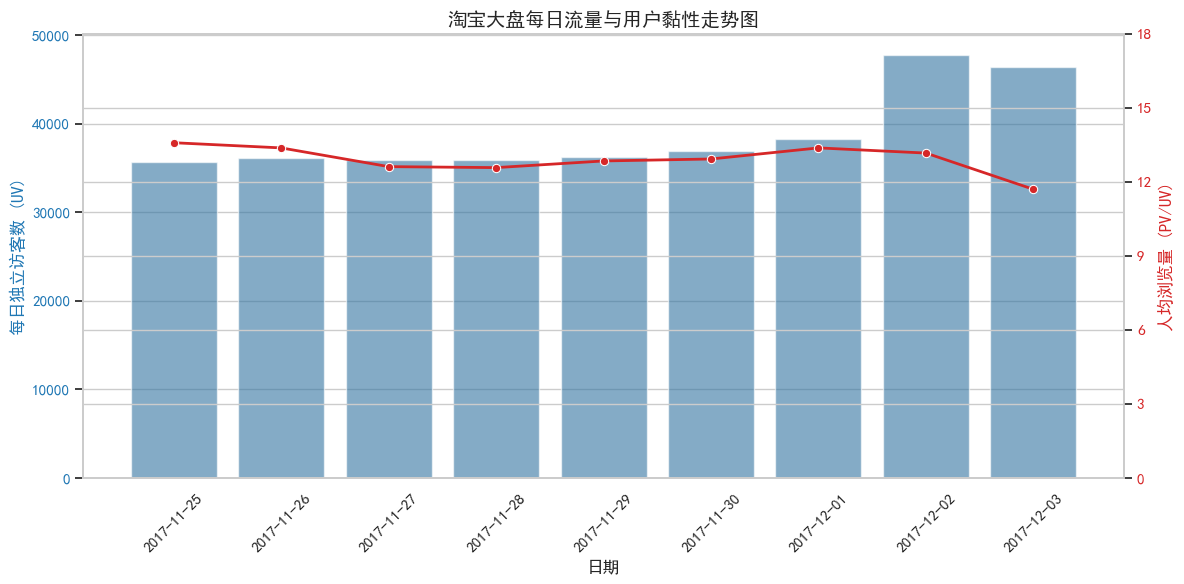

In [3]:
# 绘制双轴图同时展示 UV 柱状图与人均 PV 折线
fig, ax1 = plt.subplots(figsize=(12, 6))

# 绘制 UV 柱状图
color = 'tab:blue'
ax1.set_xlabel('日期', fontsize=12)
ax1.set_ylabel('每日独立访客数 (UV)', color=color, fontsize=12)
sns.barplot(x='date', y='total_uv', data=traffic_daily, ax=ax1, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xticks(range(len(traffic_daily)))
ax1.set_xticklabels(traffic_daily['date'], rotation=45)

# 绘制人均PV折线图
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('人均浏览量 (PV/UV)', color=color, fontsize=12)
sns.lineplot(x=range(len(traffic_daily)), y='pv_per_uv', data=traffic_daily, ax=ax2, color=color, marker='o', linewidth=2)

ax2.set_ylim(0, 18)
ax2.set_yticks(range(0, 19, 3))

ax2.tick_params(axis='y', labelcolor=color)

plt.title('淘宝大盘每日流量与用户黏性走势图', fontsize=14, fontweight='bold')
fig.tight_layout()

# 保存图表
plt.savefig(os.path.join(OUTPUTS_DIR, '01_daily_traffic_trend.png'), dpi=300, bbox_inches='tight')
plt.show()

2.时间序列分析
统计不同活跃行为（点击、加购、收藏、购买）的分时波动

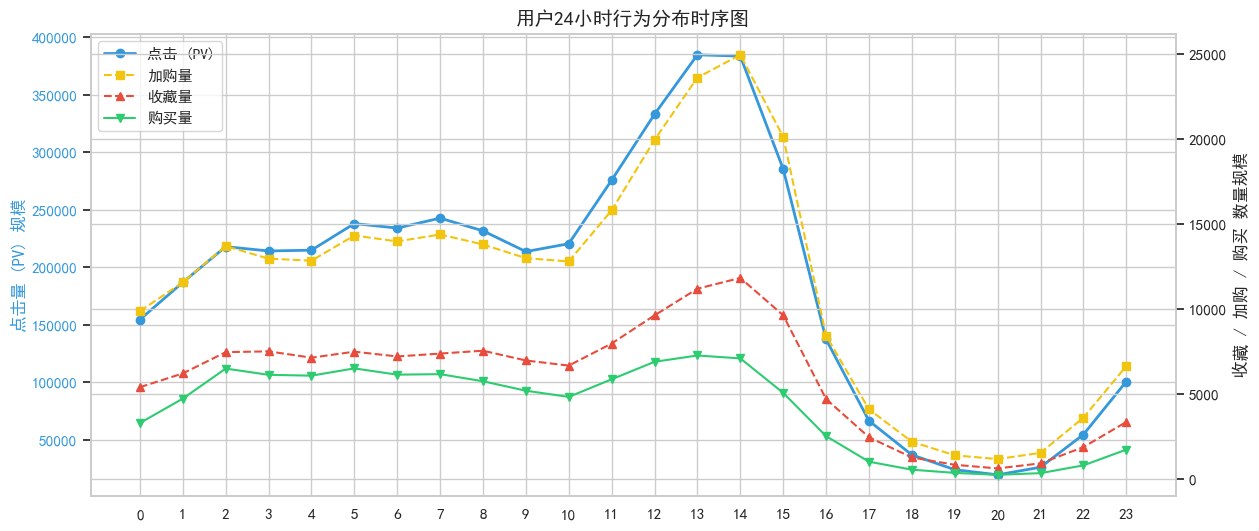

In [4]:
# 从时间戳提取小时
df_sample['hour'] = df_sample['timestamp'].dt.hour
# 按小时和行为类型计数
hourly_behavior = df_sample.groupby(['hour', 'behavior_type'], observed=True).size().unstack(fill_value=0).reset_index()

# 左轴：点击量（PV）
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(hourly_behavior['hour'], hourly_behavior['pv'], label='点击 (PV)', color='#3498db', marker='o', linewidth=2)
ax1.set_ylabel('点击量 (PV) 规模', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

# 右轴：收藏、加购、购买
ax2 = ax1.twinx()
ax2.plot(hourly_behavior['hour'], hourly_behavior['cart'], label='加购量', color='#f1c40f', marker='s', linestyle='--')
ax2.plot(hourly_behavior['hour'], hourly_behavior['fav'], label='收藏量', color='#e74c3c', marker='^', linestyle='--')
ax2.plot(hourly_behavior['hour'], hourly_behavior['buy'], label='购买量', color='#2ecc71', marker='v', linestyle='-')
ax2.set_ylabel('收藏 / 加购 / 购买 数量规模')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('用户24小时行为分布时序图', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))

plt.savefig(os.path.join(OUTPUTS_DIR, '02_hourly_behavior_timeseries.png'), dpi=300, bbox_inches='tight')
plt.show()

3.全站活跃用户转化漏斗
计算四类行为的不重复用户数，并以浏览（pv）用户为基准计算整体转化率，定位用户从浏览到购买的流失主要环节

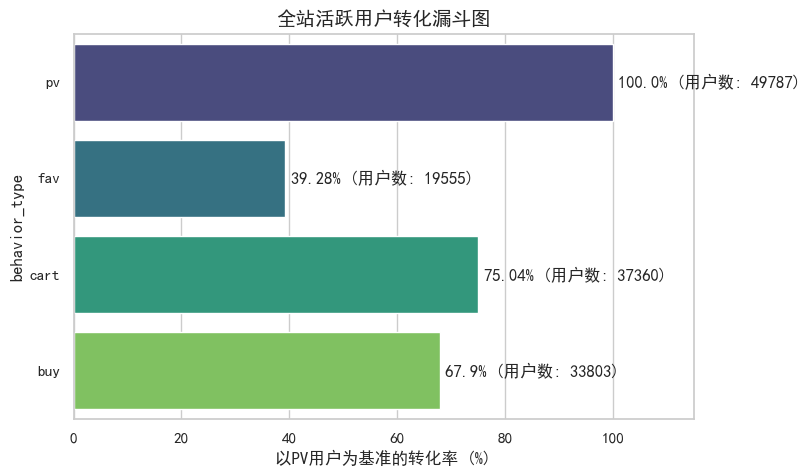

In [5]:
# 按行为类型统计去重用户数
user_funnel = df_sample.groupby('behavior_type', observed=True)['user_id'].nunique().reindex(['pv', 'fav', 'cart', 'buy'])
user_funnel_df = pd.DataFrame({'活跃用户数': user_funnel})
# 转化率：以 pv 用户数为分母
user_funnel_df['整体转化率(%)'] = (user_funnel_df['活跃用户数'] / user_funnel_df.loc['pv', '活跃用户数'] * 100).round(2)

# 绘图
plt.figure(figsize=(8, 5))

sns.barplot(
    x='整体转化率(%)', 
    y=user_funnel_df.index, 
    data=user_funnel_df, 
    hue=user_funnel_df.index, 
    palette='viridis', 
    legend=False
)

for index, value in enumerate(user_funnel_df['整体转化率(%)']):
    plt.text(value + 1, index, f"{value}% (用户数: {user_funnel_df.iloc[index, 0]})", va='center', fontweight='bold')

plt.title('全站活跃用户转化漏斗图', fontsize=14, fontweight='bold')
plt.xlim(0, 115)
plt.xlabel('以PV用户为基准的转化率 (%)')

plt.savefig(os.path.join(OUTPUTS_DIR, '03_user_conversion_funnel.png'), dpi=300, bbox_inches='tight')
plt.show()